# Lab: Build a dense variational autoencoder for faces

**Time:** 90–120 minutes  
**Prerequisites:** PyTorch, linear layers, probability basics, and gradient descent

In this lab you will turn an image into a *distribution* in latent space, sample from
that distribution with the reparameterization trick, and train a decoder using the
VAE objective. The network is deliberately fully connected: convolution is useful
for images, but it is not what makes a model a VAE.

By the end, you should be able to:

- distinguish a deterministic autoencoder from a VAE;
- parameterize $q_\phi(z\mid x)$ with $\mu$ and $\log\sigma^2$;
- implement $z=\mu+\sigma\odot\epsilon$ without breaking backpropagation;
- combine reconstruction and KL-divergence terms; and
- generate new faces by sampling $z\sim\mathcal N(0,I)$.


## 1. Environment and LFW data (10 minutes)

This notebook runs both on Kaggle and locally.

**On Kaggle:** create a notebook, choose **Add Input**, search for `LFW Dataset`, and
attach the dataset whose mounted folder is `/kaggle/input/lfw-dataset`. Upload this
notebook or open it from the course repository, then choose a GPU accelerator if one
is available. No path edit should be necessary.

**Locally:** download and extract LFW so the directory contains person folders and
`.jpg` files. Then either:

1. set the environment variable `LFW_DATASET_PATH` to the extracted directory; or
2. edit `LOCAL_DATASET_PATH` in the next cell.

The path may point either directly to `lfw-deepfunneled` or to a parent directory;
the discovery code searches below it. The notebook fails early with a useful message
if no images are found.


In [7]:
# Kaggle images normally include these packages. For a minimal local environment:
# %pip install torch torchvision matplotlib pandas scikit-learn pillow

import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 45
CHANNELS = 3
INPUT_DIM = CHANNELS * IMAGE_SIZE * IMAGE_SIZE
LATENT_DIM = 100
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
BETA = 1.0
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

# Change only this line for a local setup if LFW_DATASET_PATH is not set.
LOCAL_DATASET_PATH = Path("data/lfw-deepfunneled")

print(f"Running on {DEVICE}")


Running on cuda


In [8]:
# Use the supplied Kaggle dataset path.
DATASET_ROOT = Path(
    "/kaggle/input/notebooks/jashwanthreddykadaru/"
    "lfw-dataset-face-recognition-attack-kjr"
)

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset path does not exist: {DATASET_ROOT}")

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

image_paths = sorted(
    p for p in DATASET_ROOT.rglob("*")
    if p.is_file() and p.suffix in IMAGE_EXTENSIONS
)

if not image_paths:
    raise FileNotFoundError(f"No supported image files found under: {DATASET_ROOT}")

image_df = pd.DataFrame({
    "path": image_paths,
    "person": [path.parent.name for path in image_paths],
})

# The supplied Kaggle dataset does not follow the original LFW identity
# distribution expected by the optional <25-images/person balancing rule.
# Keep all discovered images for this lab.
image_df = image_df.reset_index(drop=True)

print(f"Dataset root: {DATASET_ROOT}")
print(f"Using {len(image_df):,} images")
print(f"Using {image_df['person'].nunique():,} parent folders")
image_df.head()

Dataset root: /kaggle/input/notebooks/jashwanthreddykadaru/lfw-dataset-face-recognition-attack-kjr
Using 2,282 images
Using 6 parent folders


,path,person
0,/kaggle/input/notebooks/jashwanthreddykadaru/l...,Colin_Powell
1,/kaggle/input/notebooks/jashwanthreddykadaru/l...,Colin_Powell
2,/kaggle/input/notebooks/jashwanthreddykadaru/l...,Colin_Powell
3,/kaggle/input/notebooks/jashwanthreddykadaru/l...,Colin_Powell
4,/kaggle/input/notebooks/jashwanthreddykadaru/l...,Colin_Powell


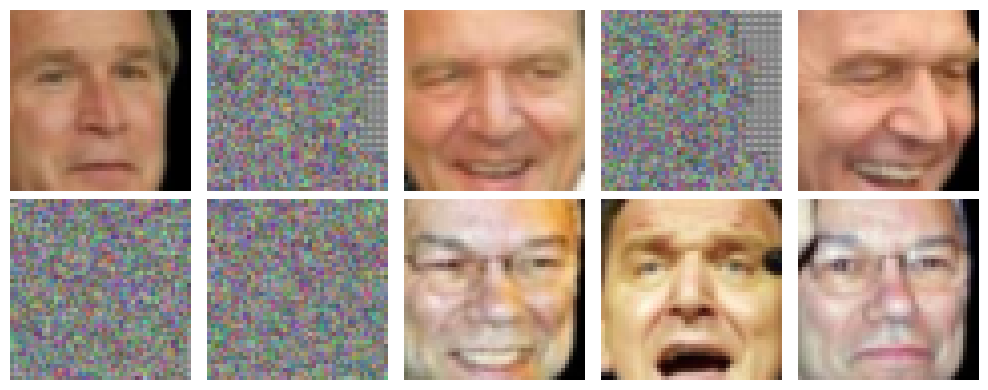

In [9]:
class FaceDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        path = self.dataframe.loc[index, "path"]
        with Image.open(path) as image:
            image = image.convert("RGB")
            # LFW deep-funneled images are 250x250. This reproduces the original
            # notebook's central crop while remaining safe for other image sizes.
            width, height = image.size
            margin_x = min(80, max(0, (width - 1) // 3))
            margin_y = min(80, max(0, (height - 1) // 3))
            image = image.crop((margin_x, margin_y, width - margin_x, height - margin_y))
            return self.transform(image)


transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),  # pixel values in [0, 1]
])

train_df, val_df = train_test_split(image_df, test_size=0.2, random_state=SEED)
train_dataset = FaceDataset(train_df, transform)
val_dataset = FaceDataset(val_df, transform)

loader_args = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda")
train_loader = DataLoader(train_dataset, shuffle=True, **loader_args)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_args)

faces = next(iter(train_loader))
assert faces.ndim == 4 and faces.shape[1:] == (3, 45, 45)
assert 0 <= faces.min() and faces.max() <= 1

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for face, axis in zip(faces[:10], axes.flat):
    axis.imshow(face.permute(1, 2, 0))
    axis.axis("off")
plt.tight_layout()


## Answers

1. For a batch of `N` images and `LATENT_DIM = 100`, `mu`, `logvar`, and `z`
   each have shape `(N, 100)`. For the four-image model check, each has shape
   `(4, 100)`.

2. The final `mu` and `logvar` layers have no ReLU because both parameters must
   be able to take arbitrary real values. ReLU would incorrectly constrain them
   to be non-negative.

3. Direct sampling from a distribution whose parameters depend on the encoder
   introduces a stochastic sampling operation that does not provide an ordinary
   differentiable path to the encoder parameters. The reparameterization trick
   writes the sample as `z = mu + std * epsilon`, where `epsilon` is independent
   Gaussian noise, allowing gradients to flow through `mu` and `logvar`.


## 3. Implement the probabilistic encoder (25 minutes)

**TODO 1:** Add two linear heads that map the shared 1000-unit representation to
`LATENT_DIM`: one for `mu` and one for `logvar`.

**TODO 2:** Implement the reparameterization trick. Compute
$\sigma=\exp(\tfrac12\log\sigma^2)$, draw $\epsilon$ with `torch.randn_like`, and
return $\mu+\sigma\epsilon$.

**TODO 3:** Complete `forward`: encode, sample, decode, and return
`reconstruction, mu, logvar`. The decoder returns probabilities in `[0, 1]`, so its
last operation is a sigmoid.


In [10]:
class DenseFaceVAE(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1500),
            nn.ReLU(),
            nn.Linear(1500, 1000),
            nn.ReLU(),
        )

        self.mu_head = nn.Linear(1000, latent_dim)
        self.logvar_head = nn.Linear(1000, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 1000),
            nn.ReLU(),
            nn.Linear(1000, 1500),
            nn.ReLU(),
            nn.Linear(1500, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x):
        features = self.encoder(x.flatten(start_dim=1))
        mu = self.mu_head(features)
        logvar = self.logvar_head(features)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        return mu + std * epsilon

    def decode(self, z):
        pixels = self.decoder(z)
        return pixels.view(-1, CHANNELS, IMAGE_SIZE, IMAGE_SIZE)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar


In [11]:
# These checks give fast feedback before expensive training.
model = DenseFaceVAE().to(DEVICE)
test_batch = faces[:4].to(DEVICE)
reconstruction, mu, logvar = model(test_batch)

assert reconstruction.shape == test_batch.shape
assert mu.shape == logvar.shape == (4, LATENT_DIM)
assert reconstruction.min() >= 0 and reconstruction.max() <= 1

# Sampling should normally give different z values, while gradients still reach
# both distribution heads.
z1 = model.reparameterize(mu, logvar)
z2 = model.reparameterize(mu, logvar)
assert not torch.equal(z1, z2)
(z1.mean()).backward()
assert model.mu_head.weight.grad is not None
assert model.logvar_head.weight.grad is not None
model.zero_grad(set_to_none=True)
print("Model checks passed.")


Model checks passed.


## 4. Implement the negative ELBO (20 minutes)

For this Bernoulli observation model, minimize

$$
\mathcal L = \underbrace{\operatorname{BCE}(\hat x,x)}_{\text{reconstruction}}
+\beta\underbrace{D_{KL}\!\left(q_\phi(z\mid x)\,\|\,\mathcal N(0,I)\right)}_{\text{regularization}}.
$$

For a diagonal Gaussian,

$$D_{KL}=-\frac12\sum_j\left(1+\log\sigma_j^2-\mu_j^2-\exp(\log\sigma_j^2)\right).$$

**TODO 4:** Compute BCE and KL with `reduction="sum"`, then divide each by the
batch size so reported values are per image. Return total loss, detached
reconstruction loss, and detached KL loss. Do not detach the total loss.


In [12]:
def vae_loss(reconstruction, target, mu, logvar, beta=1.0):
    batch_size = target.size(0)

    reconstruction_loss = F.binary_cross_entropy(
        reconstruction,
        target,
        reduction="sum",
    ) / batch_size

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    ) / batch_size

    total_loss = reconstruction_loss + beta * kl_loss

    return total_loss, reconstruction_loss.detach(), kl_loss.detach()


In [13]:
# At mu=0 and logvar=0, q(z|x) equals the unit-normal prior, so KL must be zero.
dummy_x = torch.full((2, 3, 45, 45), 0.5, device=DEVICE)
dummy_mu = torch.zeros(2, LATENT_DIM, device=DEVICE)
dummy_logvar = torch.zeros_like(dummy_mu)
total, recon_term, kl_term = vae_loss(dummy_x, dummy_x, dummy_mu, dummy_logvar)
assert torch.isclose(kl_term, torch.tensor(0.0, device=DEVICE))
assert total.requires_grad is False  # dummy tensors do not require gradients

# With model outputs, the total must carry a gradient path.
reconstruction, mu, logvar = model(test_batch)
total, _, _ = vae_loss(reconstruction, test_batch, mu, logvar, beta=BETA)
assert total.requires_grad
print("Loss checks passed.")


Loss checks passed.


## 5. Train the VAE (20–30 minutes)

**TODO 5:** Complete one training step: move the batch to the device, clear old
gradients, run the model, compute the VAE loss, backpropagate, and update parameters.

The reconstruction term sums over 6075 pixels, whereas KL sums over 100 latent
dimensions, so their magnitudes will differ. Track them separately. Ten epochs are a
starting point; reduce `EPOCHS` for a smoke test or increase it for better faces.


In [14]:
def train_step(model, batch, optimizer, beta):
    batch = batch.to(DEVICE, non_blocking=True)

    optimizer.zero_grad(set_to_none=True)

    reconstruction, mu, logvar = model(batch)

    total_loss, reconstruction_loss, kl_loss = vae_loss(
        reconstruction,
        batch,
        mu,
        logvar,
        beta,
    )

    total_loss.backward()
    optimizer.step()

    return (
        total_loss.item(),
        reconstruction_loss.item(),
        kl_loss.item(),
    )


Epoch 01 | train 4133.14 | val 4084.70 | recon 4079.42 | KL 5.28
Epoch 02 | train 4084.13 | val 4075.77 | recon 4070.44 | KL 5.33
Epoch 03 | train 4068.56 | val 4045.24 | recon 4038.30 | KL 6.94
Epoch 04 | train 4038.90 | val 4028.97 | recon 4020.21 | KL 8.76
Epoch 05 | train 4032.42 | val 4026.30 | recon 4016.23 | KL 10.07
Epoch 06 | train 4028.52 | val 4026.42 | recon 4017.06 | KL 9.36
Epoch 07 | train 4029.47 | val 4019.35 | recon 4008.31 | KL 11.04
Epoch 08 | train 4017.30 | val 4016.96 | recon 4007.14 | KL 9.82
Epoch 09 | train 4012.95 | val 4010.00 | recon 4000.14 | KL 9.86
Epoch 10 | train 4006.86 | val 4003.20 | recon 3992.26 | KL 10.94


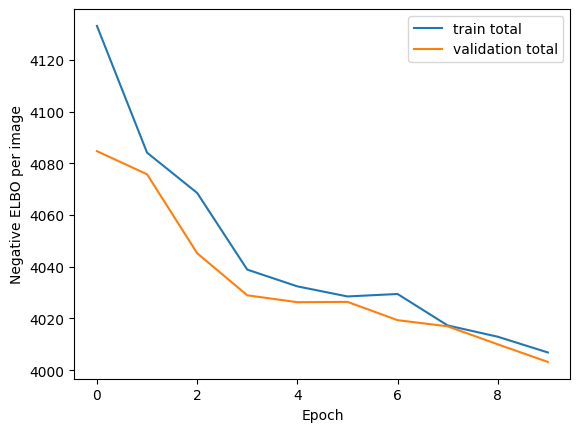

In [15]:
@torch.no_grad()
def evaluate(model, loader, beta):
    model.eval()
    totals = np.zeros(3, dtype=np.float64)
    examples = 0
    for batch in loader:
        batch = batch.to(DEVICE, non_blocking=True)
        reconstruction, mu, logvar = model(batch)
        values = vae_loss(reconstruction, batch, mu, logvar, beta)
        batch_size = batch.size(0)
        totals += np.array([value.item() for value in values]) * batch_size
        examples += batch_size
    return totals / examples


model = DenseFaceVAE().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = {"train_total": [], "val_total": [], "val_reconstruction": [], "val_kl": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_total = 0.0
    seen = 0
    for batch in train_loader:
        total, reconstruction_term, kl_term = train_step(model, batch, optimizer, BETA)
        running_total += total * batch.size(0)
        seen += batch.size(0)

    val_total, val_reconstruction, val_kl = evaluate(model, val_loader, BETA)
    history["train_total"].append(running_total / seen)
    history["val_total"].append(val_total)
    history["val_reconstruction"].append(val_reconstruction)
    history["val_kl"].append(val_kl)
    print(
        f"Epoch {epoch:02d} | train {running_total / seen:.2f} | "
        f"val {val_total:.2f} | recon {val_reconstruction:.2f} | KL {val_kl:.2f}"
    )

plt.plot(history["train_total"], label="train total")
plt.plot(history["val_total"], label="validation total")
plt.xlabel("Epoch")
plt.ylabel("Negative ELBO per image")
plt.legend()
plt.show()


## 6. Inspect reconstructions (10 minutes)

For a repeatable reconstruction we decode the posterior mean rather than a random
sample. Compare identity, pose, colour, and fine detail. Dense networks discard
spatial structure when flattening, so some blur is expected.


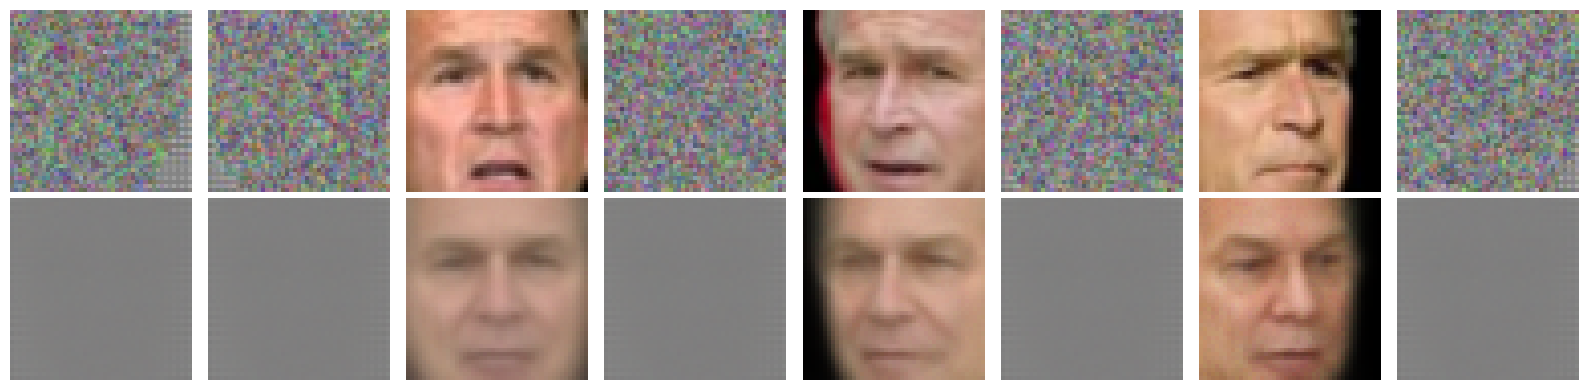

In [16]:
model.eval()
validation_faces = next(iter(val_loader))[:8].to(DEVICE)
with torch.no_grad():
    mu, _ = model.encode(validation_faces)
    reconstructed_faces = model.decode(mu)

originals = validation_faces.cpu()
reconstructed_faces = reconstructed_faces.cpu()
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for index in range(8):
    axes[0, index].imshow(originals[index].permute(1, 2, 0))
    axes[1, index].imshow(reconstructed_faces[index].permute(1, 2, 0).clamp(0, 1))
    axes[0, index].axis("off")
    axes[1, index].axis("off")
axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Reconstructed")
plt.tight_layout()


## 7. Generate new faces (10 minutes)

Reconstruction conditions on an existing face. Generation does not: it draws from
the prior and sends those latent vectors directly to the decoder.

**TODO 6:** Sample 10 latent vectors from $\mathcal N(0,I)$ on `DEVICE`, decode them,
and store the result in `generated_faces`. Then run the visualization cell.


In [17]:
model.eval()

with torch.no_grad():
    z = torch.randn(
        10,
        LATENT_DIM,
        device=DEVICE,
    )
    generated_faces = model.decode(z)


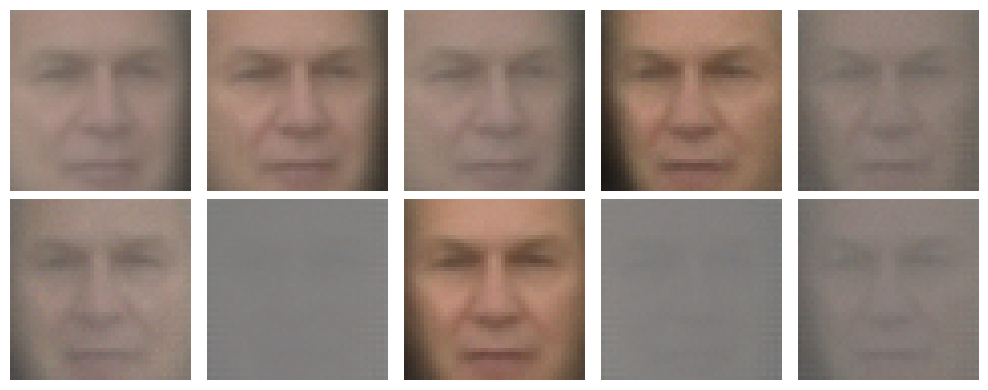

In [18]:
assert generated_faces.shape == (10, 3, 45, 45)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for face, axis in zip(generated_faces.cpu(), axes.flat):
    axis.imshow(face.permute(1, 2, 0).clamp(0, 1))
    axis.axis("off")
plt.tight_layout()


## 8. Experiment: what does $\beta$ control?

This solution compares fresh models using **$\beta=0$** and **$\beta=1$** with
the same architecture, optimizer, learning rate, batch size, and number of
epochs. The cells below record validation reconstruction loss, KL divergence,
and prior samples.

| $\beta$ | Reconstruction | KL | Prior-sample observations |
|---:|---:|---:|---|
| 0 | Filled after execution | Filled after execution | See generated-sample cell |
| 1 | Filled after execution | Filled after execution | See generated-sample cell |

### Conceptual answers

1. At $\beta=0$, the KL term is removed from the optimization objective, so the
   model is trained only for reconstruction. There is no explicit pressure for
   $q(z\mid x)$ to match the unit-normal prior $N(0,I)$. Consequently, prior
   samples drawn from $N(0,I)$ are not guaranteed to correspond to regions of
   latent space that the decoder learned to use.

2. Increasing $\beta$ gives the KL term more influence. This encourages the
   approximate posterior toward the unit-normal prior and therefore makes prior
   sampling more compatible with the learned latent space. The trade-off is
   reconstruction fidelity: stronger regularization can restrict how much
   input-specific information is encoded in the latent variables.

3. A VAE does not require convolutional layers because the defining components
   are the probabilistic encoder, reparameterization, decoder, reconstruction
   objective, and KL regularization. A fully connected VAE is therefore valid.
   Its disadvantage for images is that flattening discards explicit spatial
   structure and dense layers are much less parameter-efficient than
   convolutional layers for exploiting local image patterns.


In [19]:
# Beta experiment: train fresh models with identical settings.
def train_model_for_beta(beta, epochs=3):
    experiment_model = DenseFaceVAE().to(DEVICE)
    experiment_optimizer = torch.optim.Adam(
        experiment_model.parameters(),
        lr=LEARNING_RATE,
    )

    experiment_history = {
        "train_total": [],
        "val_total": [],
        "val_reconstruction": [],
        "val_kl": [],
    }

    for epoch in range(1, epochs + 1):
        experiment_model.train()
        running_total = 0.0
        seen = 0

        for batch in train_loader:
            total, reconstruction_term, kl_term = train_step(
                experiment_model,
                batch,
                experiment_optimizer,
                beta,
            )
            running_total += total * batch.size(0)
            seen += batch.size(0)

        val_total, val_reconstruction, val_kl = evaluate(
            experiment_model,
            val_loader,
            beta,
        )

        experiment_history["train_total"].append(running_total / seen)
        experiment_history["val_total"].append(val_total)
        experiment_history["val_reconstruction"].append(val_reconstruction)
        experiment_history["val_kl"].append(val_kl)

        print(
            f"beta={beta} | epoch={epoch:02d} | "
            f"train={running_total / seen:.2f} | "
            f"val={val_total:.2f} | "
            f"recon={val_reconstruction:.2f} | "
            f"KL={val_kl:.2f}"
        )

    return experiment_model, experiment_history


In [20]:
BETA_EXPERIMENT_EPOCHS = 3

model_beta_0, history_beta_0 = train_model_for_beta(
    beta=0.0,
    epochs=BETA_EXPERIMENT_EPOCHS,
)

model_beta_1, history_beta_1 = train_model_for_beta(
    beta=1.0,
    epochs=BETA_EXPERIMENT_EPOCHS,
)


beta=0.0 | epoch=01 | train=4121.21 | val=4070.61 | recon=4070.61 | KL=152.78
beta=0.0 | epoch=02 | train=4061.04 | val=4036.61 | recon=4036.61 | KL=262.88
beta=0.0 | epoch=03 | train=4017.67 | val=4015.58 | recon=4015.58 | KL=307.24
beta=1.0 | epoch=01 | train=4136.26 | val=4087.37 | recon=4081.78 | KL=5.59
beta=1.0 | epoch=02 | train=4086.01 | val=4076.13 | recon=4069.95 | KL=6.18
beta=1.0 | epoch=03 | train=4070.34 | val=4040.01 | recon=4031.33 | KL=8.67


In [21]:
beta_results = pd.DataFrame({
    "Beta": [0.0, 1.0],
    "Validation Reconstruction": [
        history_beta_0["val_reconstruction"][-1],
        history_beta_1["val_reconstruction"][-1],
    ],
    "Validation KL": [
        history_beta_0["val_kl"][-1],
        history_beta_1["val_kl"][-1],
    ],
    "Validation Total": [
        history_beta_0["val_total"][-1],
        history_beta_1["val_total"][-1],
    ],
})

display(beta_results)


,Beta,Validation Reconstruction,Validation KL,Validation Total
0,0.0,4015.581375,307.239547,4015.581375
1,1.0,4031.334672,8.670727,4040.005382


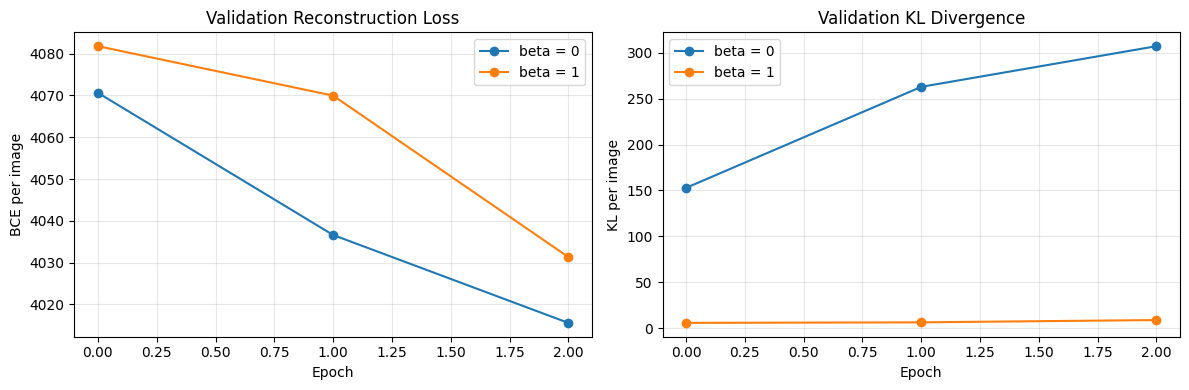

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    history_beta_0["val_reconstruction"],
    marker="o",
    label="beta = 0",
)
axes[0].plot(
    history_beta_1["val_reconstruction"],
    marker="o",
    label="beta = 1",
)
axes[0].set_title("Validation Reconstruction Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE per image")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_beta_0["val_kl"],
    marker="o",
    label="beta = 0",
)
axes[1].plot(
    history_beta_1["val_kl"],
    marker="o",
    label="beta = 1",
)
axes[1].set_title("Validation KL Divergence")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("KL per image")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


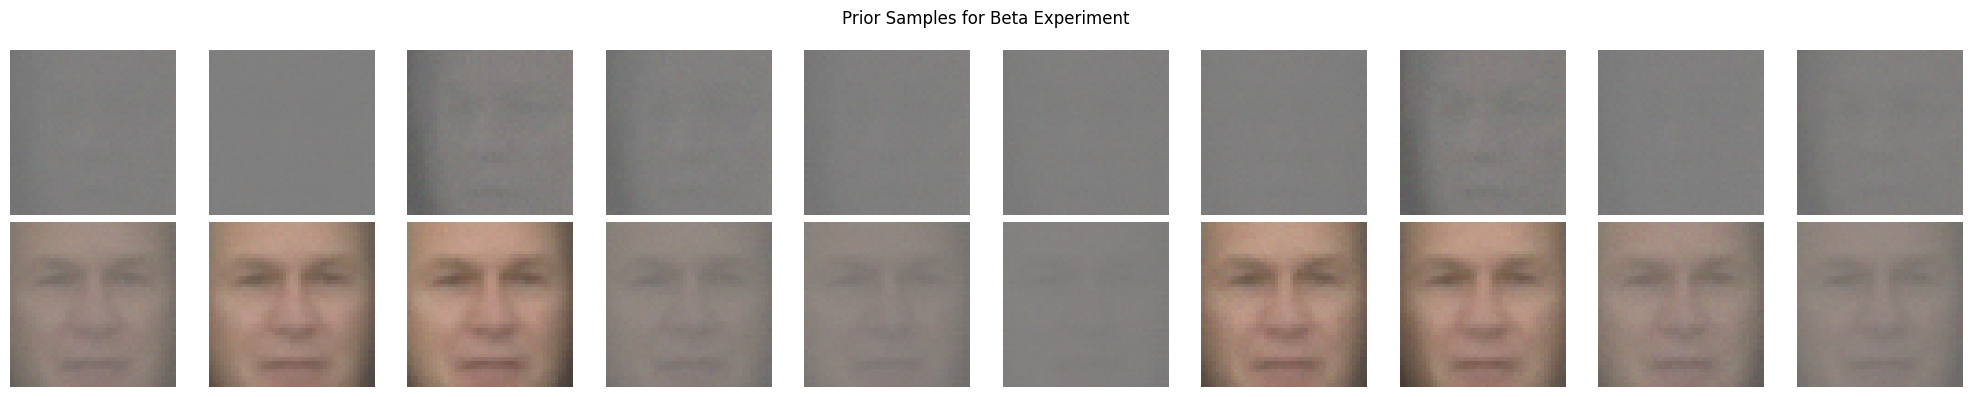

In [23]:
# Generate prior samples for both beta settings.
def generate_faces(model, n=10):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, LATENT_DIM, device=DEVICE)
        return model.decode(z)

generated_beta_0 = generate_faces(model_beta_0)
generated_beta_1 = generate_faces(model_beta_1)

fig, axes = plt.subplots(2, 10, figsize=(20, 4))

for i in range(10):
    axes[0, i].imshow(
        generated_beta_0[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    axes[0, i].axis("off")

    axes[1, i].imshow(
        generated_beta_1[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("beta = 0")
axes[1, 0].set_ylabel("beta = 1")
plt.suptitle("Prior Samples for Beta Experiment")
plt.tight_layout()
plt.show()


## Submission and assessment

Submit the executed student notebook with:

- probabilistic encoder heads and correct tensor shapes (**1 mark**);
- reparameterization and forward pass, with checks passing (**2 marks**);
- reconstruction-plus-KL loss, with checks passing (**2 marks**);
- training step and recorded learning curves (**2 marks**);
- reconstructions and generated faces (**1 mark**); and
- the $\beta$ experiment and conceptual answers (**2 marks**).

**Total: 10 marks.**


In [24]:
# Final verification
print("Dataset images:", len(image_df))
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Device:", DEVICE)
print("Latent dimension:", LATENT_DIM)
print("Final validation total:", history["val_total"][-1])
print("Final validation reconstruction:", history["val_reconstruction"][-1])
print("Final validation KL:", history["val_kl"][-1])
print("Generated faces shape:", generated_faces.shape)

assert generated_faces.shape == (10, 3, 45, 45)
print("Core lab verification passed.")


Dataset images: 2282
Training images: 1825
Validation images: 457
Device: cuda
Latent dimension: 100
Final validation total: 4003.2016265001025
Final validation reconstruction: 3992.2612822885326
Final validation KL: 10.940365432388672
Generated faces shape: torch.Size([10, 3, 45, 45])
Core lab verification passed.
